In [2]:
%matplotlib inline

In [3]:
import pickle
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import ovrlpy
import polars as pl

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
import sys

sys.path.append("..")

from ovrlpy._plotting import _plot_signal_integrity

from utils import CM, FONT, label_kwargs

matplotlib.rc("font", **FONT)

In [5]:
um_p_px = 0.2125

In [6]:
data_folder = Path(
    "/dh-projects/ag-ishaque/raw_data/xenium/Xenium_Prime_Mouse_Pup_FFPE/Xenium_Prime_Mouse_Pup_FFPE"
)

In [7]:
out_dir = Path("./figures")
out_dir.mkdir(exist_ok=True)

In [8]:
coordinate_df = ovrlpy.io.read_Xenium(data_folder / "transcripts.parquet")

print(
    f"Number of genes: {coordinate_df['gene'].n_unique():,}",
    f"Number of molecules: {coordinate_df.shape[0]:,}",
    sep="\n",
)

Number of genes: 5,010
Number of molecules: 661,504,132


In [12]:
x, y = coordinate_df["x", "y"].max().row(0)

In [9]:
from scipy.sparse import coo_array


def pixel_gene_count(df, gridsize, coord=["x", "y"]):
    pixelcount = (
        df.with_columns(pl.col(x).floordiv(gridsize).cast(int) for x in coord)
        .group_by(coord)
        .len(name="count")
    )
    return count_df_to_arr(pixelcount, coord)


def count_df_to_arr(df, coord=["x", "y"]):
    count = (
        coo_array(
            (df["count"].to_numpy(), (df[coord[0]].to_numpy(), df[coord[1]].to_numpy()))
        )
        .toarray()
        .astype(float)
    )
    count[count == 0] = np.nan
    return count


counts = pixel_gene_count(coordinate_df, 5)

In [ ]:
mouse_pup_all = ovrlpy.Ovrlp(
    coordinate_df, n_components=50, n_workers=16, random_state=42
)

mouse_pup_all.process_coordinates(shift=False)
mouse_pup_all.fit_transcripts(min_transcripts=20)
mouse_pup_all.compute_VSI()

with open("mouse_pup_all.pickle", "wb") as file:
    pickle.dump(mouse_pup_all, file)

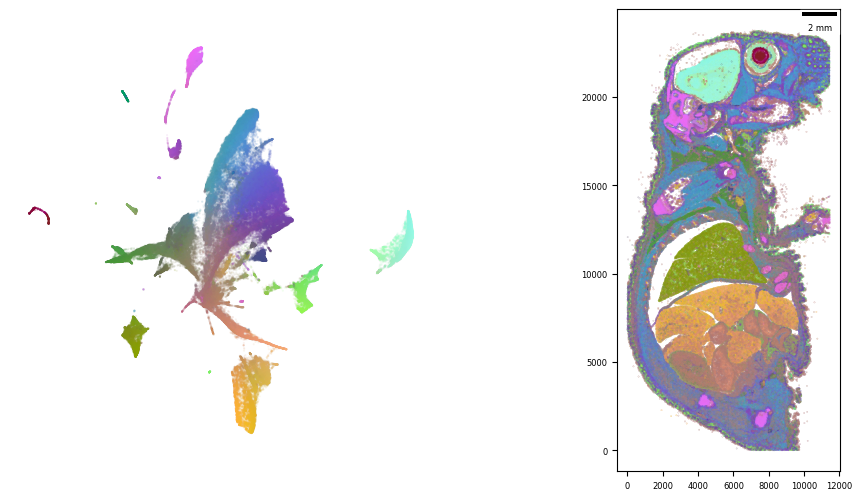

In [11]:
_ = ovrlpy.plot_pseudocells(mouse_pup_all, tissue_kwargs={"s": 0.1})

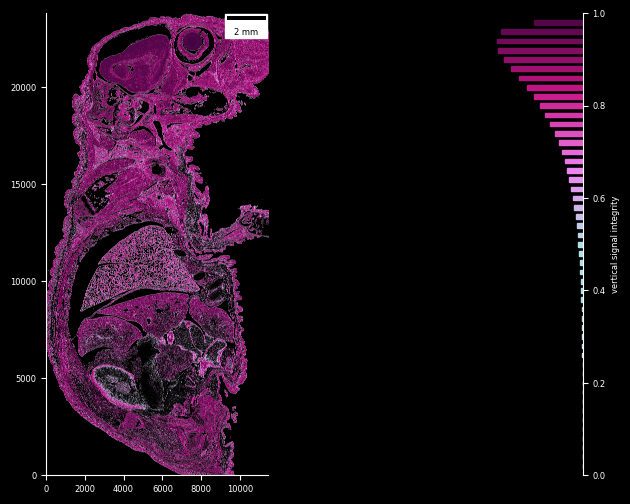

In [21]:
_ = ovrlpy.plot_signal_integrity(mouse_pup_all)

In [14]:
import tifffile
from skimage.transform import resize

with tifffile.TiffReader(
    data_folder / "morphology_focus" / "morphology_focus_0000.ome.tif"
) as dapi_tif:
    dapi = dapi_tif.pages[0].asarray()
    dapi = resize(
        dapi, output_shape=tuple(int(s * um_p_px) for s in dapi.shape), mode="constant"
    )

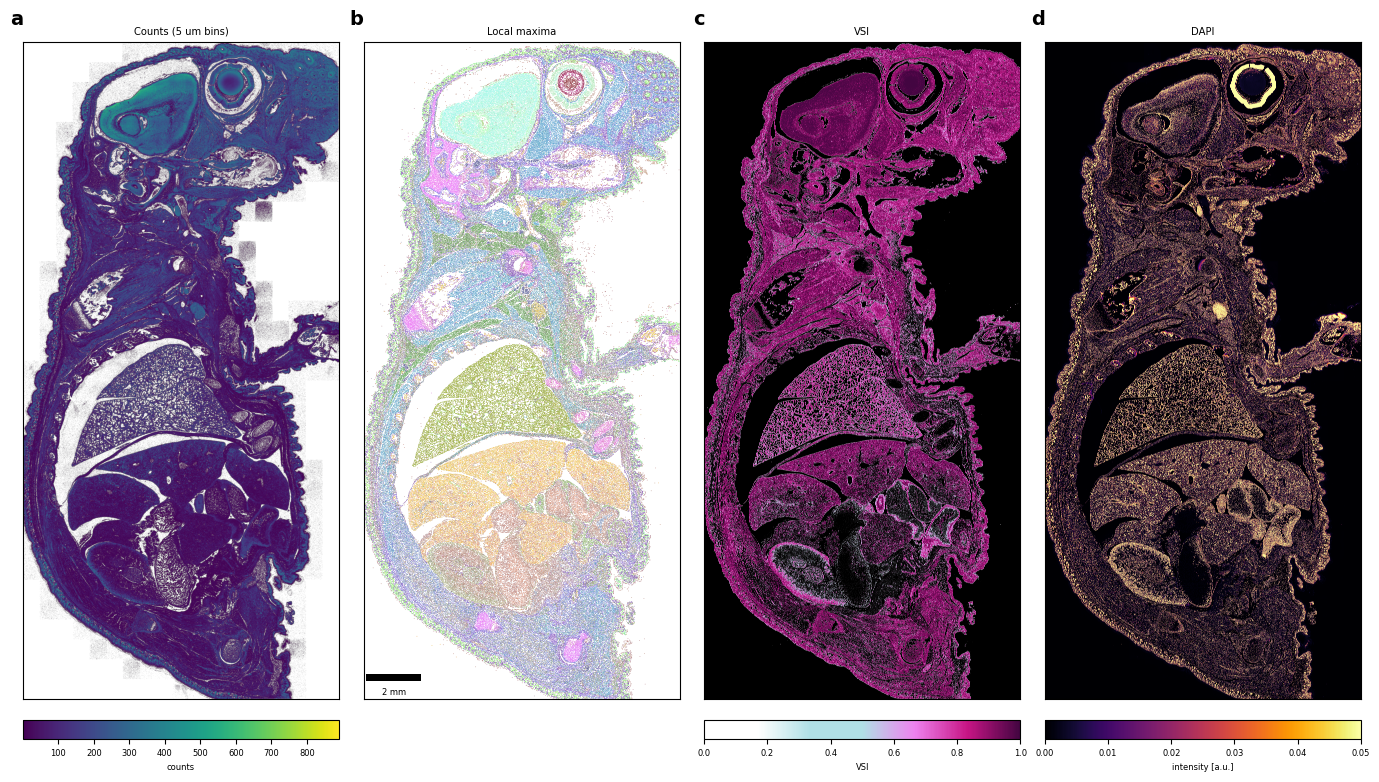

In [47]:
fig, axs = plt.subplots(
    nrows=2, ncols=4, figsize=(35 * CM, 20 * CM), height_ratios=[40, 1]
)

im = axs[0, 0].imshow(counts.T, origin="lower")
axs[0, 0].set(title="Counts (5 um bins)")
fig.colorbar(im, cax=axs[1, 0], label="counts", orientation="horizontal")

_ = ovrlpy.plot_tissue(
    mouse_pup_all,
    ax=axs[0, 1],
    s=1,
    lw=0,
    scalebar={"dx": 1, "units": "um", "loc": "lower left", "frameon": False},
)
axs[0, 1].set(xlim=(0, x), ylim=(0, y), title="Local maxima")

im = _plot_signal_integrity(
    axs[0, 2], mouse_pup_all.integrity_map, mouse_pup_all.signal_map, 2
)
axs[0, 2].set(facecolor="black", title="VSI")
fig.colorbar(im, cax=axs[1, 2], label="VSI", orientation="horizontal")

im = axs[0, 3].imshow(dapi, vmax=0.05, origin="lower", cmap="inferno")
axs[0, 3].set(title="DAPI")
fig.colorbar(im, cax=axs[1, 3], label="intensity [a.u.]", orientation="horizontal")

for ax in axs[0].ravel():
    ax.set(yticks=[], xticks=[])

axs[1, 1].set_axis_off()

for ax, l in zip(axs[0, :], "abcd"):
    ax.text(0, 1.05, l, transform=ax.transAxes, **label_kwargs)

fig.tight_layout()
fig.savefig("mousepup.png", dpi=600)